In [3]:
import importlib
import os
import subprocess
import sys
import warnings
from glob import glob


def ensure_package(module_name, package_name=None):
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        package_name = package_name or module_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.import_module(module_name)


for module_name, package_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("cv2", "opencv-python"),
    ("PIL", "pillow"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("tensorflow", "tensorflow"),
]:
    ensure_package(module_name, package_name)

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping, ReduceLROnPlateau)
from tensorflow.keras import backend as K
warnings.filterwarnings("ignore")


In [7]:
base_path = "C:\\Users\\petem\\Desktop\\Intern shi\\Brain-Tumor-Semantic-Segmentation\\train" 
image_dir = os.path.join(base_path, "images") 
mask_dir = os.path.join(base_path, "masks")
image_paths = sorted(glob(os.path.join(image_dir, "*.*"))) 
mask_paths = sorted(glob(os.path.join(mask_dir, "*.*"))) 
df = pd.DataFrame({ "image_path": image_paths, "mask_path": mask_paths })
df.head()

,image_path,mask_path
0,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
1,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
2,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
3,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
4,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...


In [8]:
df.tail()

,image_path,mask_path
3928,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
3929,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
3930,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
3931,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...
3932,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...,C:\Users\petem\Desktop\Intern shi\Brain-Tumor-...


In [9]:
df.shape

(3933, 2)

In [10]:
df.columns

Index(['image_path', 'mask_path'], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3933 entries, 0 to 3932
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3933 non-null   object
 1   mask_path   3933 non-null   object
dtypes: object(2)
memory usage: 61.6+ KB


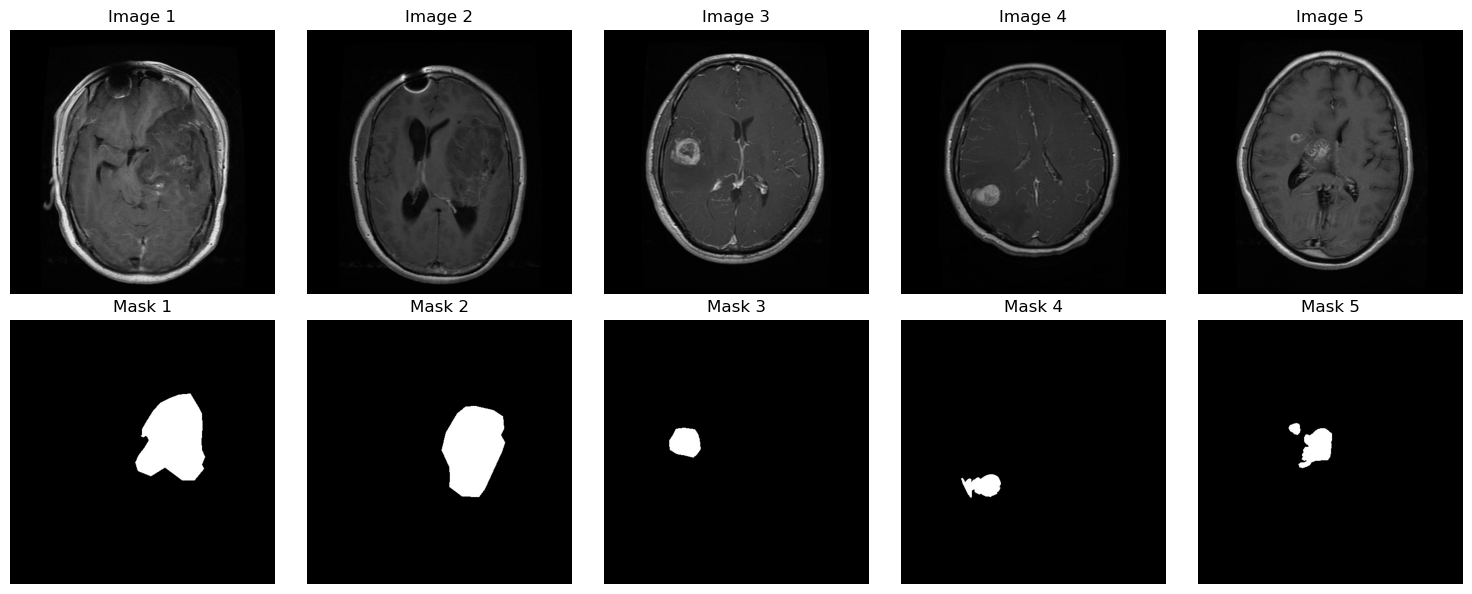

In [12]:
import matplotlib.pyplot as plt 
import cv2 
num_samples = 5 
plt.figure(figsize=(15, 6)) 
for i in range(num_samples):
    img_path = df.iloc[i]["image_path"]
    mask_path = df.iloc[i]["mask_path"] 
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) 
    plt.subplot(2, num_samples, i + 1) 
    plt.imshow(img, cmap="gray") 
    plt.title(f"Image {i+1}") 
    plt.axis("off") 
    plt.subplot(2, num_samples, num_samples + i + 1) 
    plt.imshow(mask, cmap="gray") 
    plt.title(f"Mask {i+1}") 
    plt.axis("off") 
plt.tight_layout() 
plt.show()

In [13]:
import os
from glob import glob
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 2       #30 

In [14]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 3146
Validation: 787


In [15]:
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Image not found: {path}")

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)

    return img


def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Mask not found: {path}")

    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask = mask.astype("float32") / 255.0
    mask = (mask > 0.5).astype("float32")
    mask = np.expand_dims(mask, axis=-1)

    return mask

In [16]:
def data_generator(df, batch_size=8, shuffle=True):
    df = df.reset_index(drop=True)

    while True:
        if shuffle:
            df = df.sample(frac=1).reset_index(drop=True)

        for start in range(0, len(df), batch_size):
            batch_df = df.iloc[start:start + batch_size]

            images = []
            masks = []

            for _, row in batch_df.iterrows():
                img = load_image(row["image_path"])
                mask = load_mask(row["mask_path"])

                images.append(img)
                masks.append(mask)

            yield np.array(images), np.array(masks)

In [17]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

In [19]:
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x


def build_unet(input_shape=(256, 256, 1)):
    inputs = tf.keras.Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)

    bottleneck = conv_block(p4, 512)

    u1 = tf.keras.layers.UpSampling2D((2, 2))(bottleneck)
    u1 = tf.keras.layers.Concatenate()([u1, c4])
    c5 = conv_block(u1, 256)

    u2 = tf.keras.layers.UpSampling2D((2, 2))(c5)
    u2 = tf.keras.layers.Concatenate()([u2, c3])
    c6 = conv_block(u2, 128)

    u3 = tf.keras.layers.UpSampling2D((2, 2))(c6)
    u3 = tf.keras.layers.Concatenate()([u3, c2])
    c7 = conv_block(u3, 64)

    u4 = tf.keras.layers.UpSampling2D((2, 2))(c7)
    u4 = tf.keras.layers.Concatenate()([u4, c1])
    c8 = conv_block(u4, 32)

    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(c8)

    model = tf.keras.Model(inputs, outputs)

    return model

In [20]:
train_gen = data_generator(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_gen = data_generator(val_df, batch_size=BATCH_SIZE, shuffle=False)

steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)
validation_steps = max(1, len(val_df) // BATCH_SIZE)

In [21]:
model = build_unet()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[dice_coef, iou_metric]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 7,857,857 (29.98 MB)

 Trainable params: 7,851,969 (29.95 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [22]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet_model.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        patience=10,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [23]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/2
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0509 - iou_metric: 0.0262 - loss: 0.6184
Epoch 1: val_dice_coef improved from None to 0.03800, saving model to best_unet_model.keras

Epoch 1: finished saving model to best_unet_model.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 788s 2s/step - dice_coef: 0.0569 - iou_metric: 0.0294 - loss: 0.5448 - val_dice_coef: 0.0380 - val_iou_metric: 0.0194 - val_loss: 0.4034 - learning_rate: 1.0000e-04
Epoch 2/2
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0756 - iou_metric: 0.0395 - loss: 0.3929
Epoch 2: val_dice_coef improved from 0.03800 to 0.09274, saving model to best_unet_model.keras

Epoch 2: finished saving model to best_unet_model.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - dice_coef: 0.0790 - iou_metric: 0.0413 - loss: 0.3601 - val_dice_coef: 0.0927 - val_iou_metric: 0.0488 - val_loss: 0.2603 - learning_rate: 1.0000e-04


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


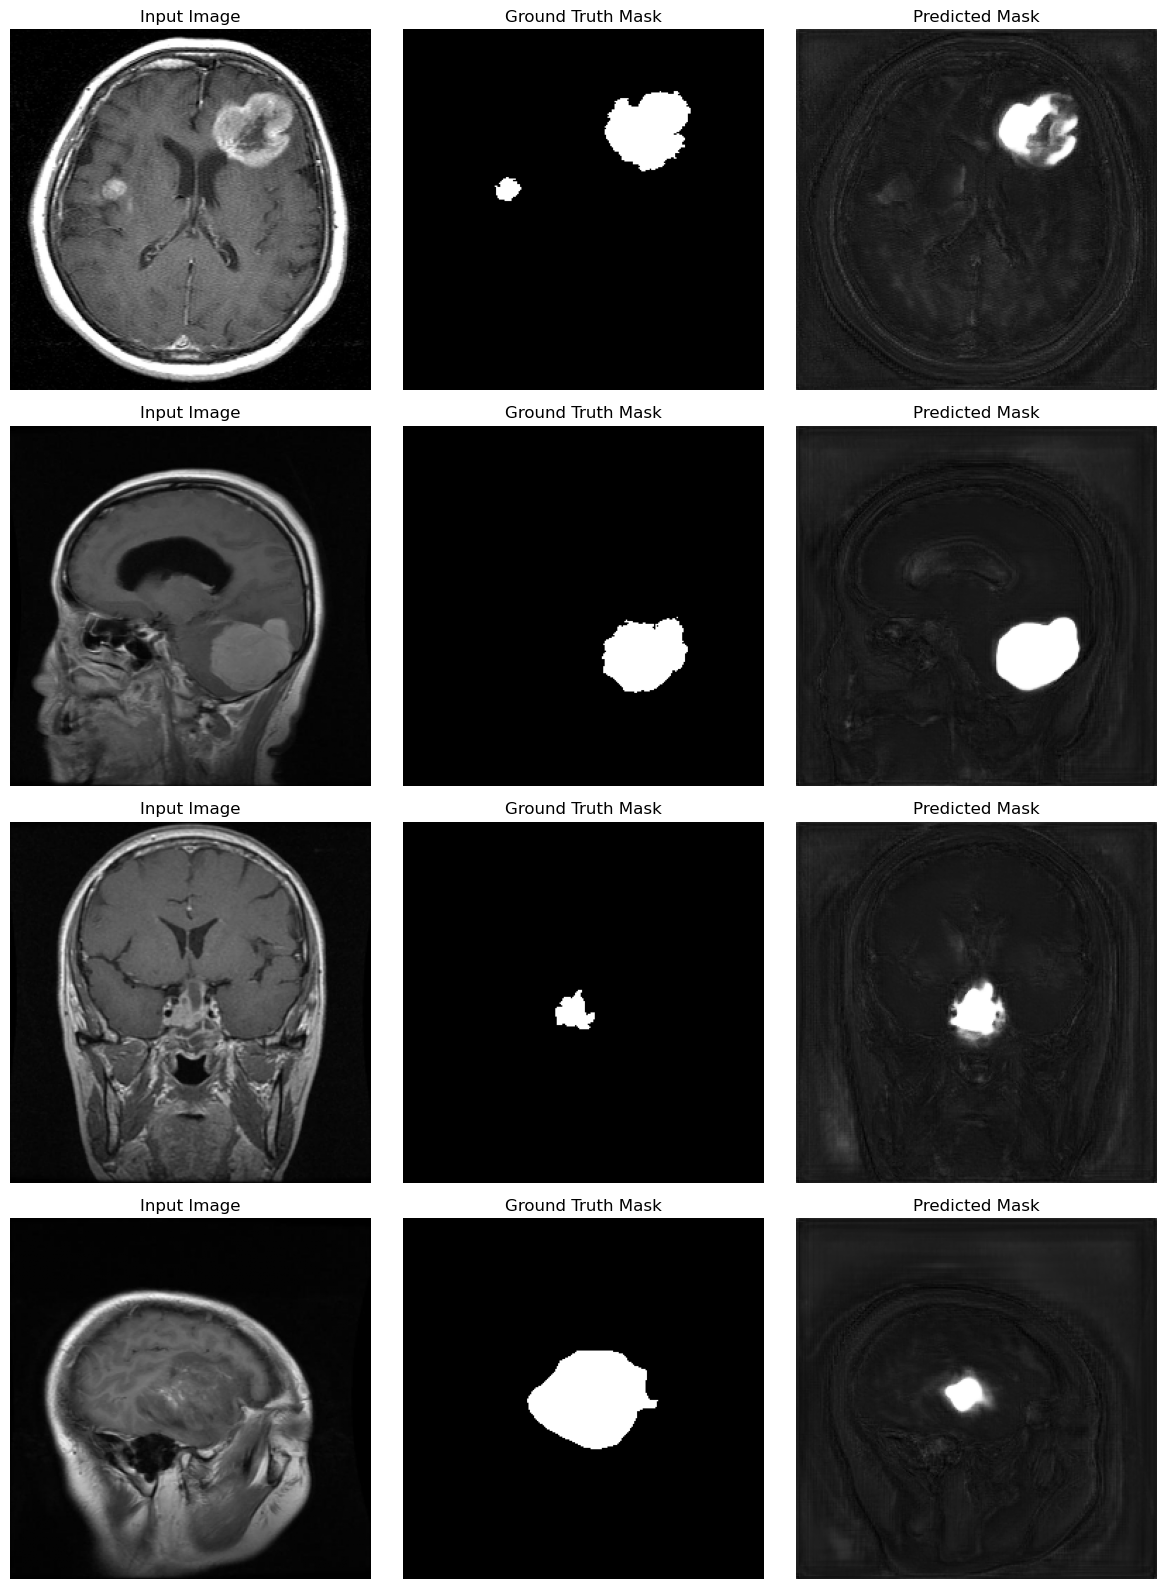

In [24]:
model.load_weights("best_unet_model.keras")

val_images, true_masks = next(val_gen)
pred_masks = model.predict(val_images)

num_samples = min(4, len(val_images))

plt.figure(figsize=(12, 4 * num_samples))

for i in range(num_samples):
    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(val_images[i, ..., 0], cmap="gray")
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(true_masks[i, ..., 0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(pred_masks[i, ..., 0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [26]:
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 2  #30
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

In [27]:
class PatchExtractor(tf.keras.layers.Layer):
    def __init__(self, patch_size=16, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, inputs):
        patches = tf.image.extract_patches(
            images=inputs,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        return patches

In [28]:
def build_optimized_cross_attention_vit(
    image_size=256,
    patch_size=16,
    embedding_dim=128,
    num_layers=4,
    num_heads=4,
    mlp_dim=256,
    dropout=0.1
):
    img_input = tf.keras.Input(
        shape=(image_size, image_size, 1),
        name="image_input"
    )

    query_positions = tf.keras.Input(
        shape=((image_size // patch_size) ** 2,),
        dtype="int32",
        name="query_positions"
    )

    grid_size = image_size // patch_size
    num_patches = grid_size * grid_size
    patch_dim = patch_size * patch_size

    # CNN skip connections
    skip_1 = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(img_input)

    skip_2 = tf.keras.layers.MaxPooling2D(2)(skip_1)
    skip_2 = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(skip_2)

    skip_3 = tf.keras.layers.MaxPooling2D(2)(skip_2)
    skip_3 = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(skip_3)

    skip_4 = tf.keras.layers.MaxPooling2D(2)(skip_3)
    skip_4 = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(skip_4)

    # Patch extraction
    img_patches = PatchExtractor(patch_size)(img_input)

    img_flat = tf.keras.layers.Reshape(
        target_shape=(num_patches, patch_dim)
    )(img_patches)

    img_proj = tf.keras.layers.Dense(
        embedding_dim,
        name="img_projection"
    )(img_flat)

    # Positional embedding
    pos_layer = tf.keras.layers.Embedding(
        input_dim=num_patches,
        output_dim=embedding_dim
    )

    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embed = pos_layer(positions)
    pos_embed = tf.expand_dims(pos_embed, axis=0)

    x = img_proj + pos_embed

    # Transformer encoder
    for _ in range(num_layers):
        norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

        attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim // num_heads,
            dropout=dropout
        )(norm1, norm1)

        x = tf.keras.layers.Add()([x, attn])

        norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

        mlp = tf.keras.layers.Dense(mlp_dim, activation="gelu")(norm2)
        mlp = tf.keras.layers.Dropout(dropout)(mlp)
        mlp = tf.keras.layers.Dense(embedding_dim)(mlp)
        mlp = tf.keras.layers.Dropout(dropout)(mlp)

        x = tf.keras.layers.Add()([x, mlp])

    img_encoded_feats = x

    # Learnable query tokens
    latent_queries = tf.keras.layers.Embedding(
        input_dim=num_patches,
        output_dim=embedding_dim
    )(query_positions)

    cross_norm_q = tf.keras.layers.LayerNormalization(epsilon=1e-6)(latent_queries)
    cross_norm_kv = tf.keras.layers.LayerNormalization(epsilon=1e-6)(img_encoded_feats)

    cross_attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embedding_dim // num_heads,
        name="image_to_patch_cross_attention"
    )(
        query=cross_norm_q,
        value=cross_norm_kv,
        key=cross_norm_kv
    )

    cross_feats = tf.keras.layers.Add()([latent_queries, cross_attn])

    mlp_cross_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(cross_feats)

    mlp_cross = tf.keras.layers.Dense(mlp_dim, activation="gelu")(mlp_cross_norm)
    mlp_cross = tf.keras.layers.Dropout(dropout)(mlp_cross)
    mlp_cross = tf.keras.layers.Dense(embedding_dim)(mlp_cross)

    final_tokens = tf.keras.layers.Add()([cross_feats, mlp_cross])

    grid_mapped = tf.keras.layers.Reshape(
        target_shape=(grid_size, grid_size, embedding_dim)
    )(final_tokens)

    # Decoder
    dec1 = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(grid_mapped)
    dec1 = tf.keras.layers.BatchNormalization()(dec1)
    dec1 = tf.keras.layers.UpSampling2D(size=2)(dec1)
    dec1 = tf.keras.layers.Concatenate()([dec1, skip_4])

    dec2 = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(dec1)
    dec2 = tf.keras.layers.BatchNormalization()(dec2)
    dec2 = tf.keras.layers.UpSampling2D(size=2)(dec2)
    dec2 = tf.keras.layers.Concatenate()([dec2, skip_3])

    dec3 = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(dec2)
    dec3 = tf.keras.layers.BatchNormalization()(dec3)
    dec3 = tf.keras.layers.UpSampling2D(size=2)(dec3)
    dec3 = tf.keras.layers.Concatenate()([dec3, skip_2])

    dec4 = tf.keras.layers.Conv2D(8, 3, padding="same", activation="relu")(dec3)
    dec4 = tf.keras.layers.BatchNormalization()(dec4)
    dec4 = tf.keras.layers.UpSampling2D(size=2)(dec4)
    dec4 = tf.keras.layers.Concatenate()([dec4, skip_1])

    dec4 = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(dec4)

    mask_output = tf.keras.layers.Conv2D(
        1,
        1,
        activation="sigmoid",
        name="mask_output"
    )(dec4)

    model = tf.keras.Model(
        inputs=[img_input, query_positions],
        outputs=mask_output
    )

    return model

In [29]:
def batch_generator(df, batch_size, num_patches=256, shuffle=True):
    df = df.reset_index(drop=True)
    pos_indices = np.arange(num_patches)

    while True:
        if shuffle:
            df = df.sample(frac=1).reset_index(drop=True)

        for start in range(0, len(df), batch_size):
            batch_df = df.iloc[start:start + batch_size]

            batch_images = []
            batch_masks = []
            batch_pos = []

            for _, row in batch_df.iterrows():
                img = load_image(row["image_path"])
                mask = load_mask(row["mask_path"])

                batch_images.append(img)
                batch_masks.append(mask)
                batch_pos.append(pos_indices)

            yield {
                "image_input": np.array(batch_images),
                "query_positions": np.array(batch_pos)
            }, np.array(batch_masks)

In [30]:
train_gen = batch_generator(
    train_df,
    batch_size=BATCH_SIZE,
    num_patches=NUM_PATCHES,
    shuffle=True
)

val_gen = batch_generator(
    val_df,
    batch_size=BATCH_SIZE,
    num_patches=NUM_PATCHES,
    shuffle=False
)

steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)
validation_steps = max(1, len(val_df) // BATCH_SIZE)

In [31]:
model = build_optimized_cross_attention_vit(
    image_size=IMG_SIZE,
    patch_size=PATCH_SIZE
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, 16, 16,    │          0 │ image_input[0][0] │
│ (PatchExtractor)    │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 256, 256)  │          0 │ patch_extractor[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_projection      │ (None, 256, 128)  │     32,896 │ reshape[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ img_projection[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 128)  │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256, 128)  │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 128)  │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 128)  │          0 │ add_2[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256, 256)  │     33,024 │ layer_normalizat

 Total params: 927,577 (3.54 MB)

 Trainable params: 927,337 (3.54 MB)

 Non-trainable params: 240 (960.00 B)

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[dice_coef, iou_metric]
)

In [34]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_optimized_model.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        patience=10,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [35]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/2
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - dice_coef: 0.0444 - iou_metric: 0.0230 - loss: 0.2443
Epoch 1: val_dice_coef improved from None to 0.19328, saving model to best_optimized_model.keras

Epoch 1: finished saving model to best_optimized_model.keras
786/786 ━━━━━━━━━━━━━━━━━━━━ 179s 210ms/step - dice_coef: 0.0790 - iou_metric: 0.0423 - loss: 0.1292 - val_dice_coef: 0.1933 - val_iou_metric: 0.1090 - val_loss: 0.0529 - learning_rate: 1.0000e-04
Epoch 2/2
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - dice_coef: 0.2488 - iou_metric: 0.1467 - loss: 0.0473
Epoch 2: val_dice_coef improved from 0.19328 to 0.21028, saving model to best_optimized_model.keras

Epoch 2: finished saving model to best_optimized_model.keras
786/786 ━━━━━━━━━━━━━━━━━━━━ 167s 212ms/step - dice_coef: 0.2986 - iou_metric: 0.1817 - loss: 0.0444 - val_dice_coef: 0.2103 - val_iou_metric: 0.1195 - val_loss: 0.1085 - learning_rate: 1.0000e-04


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step


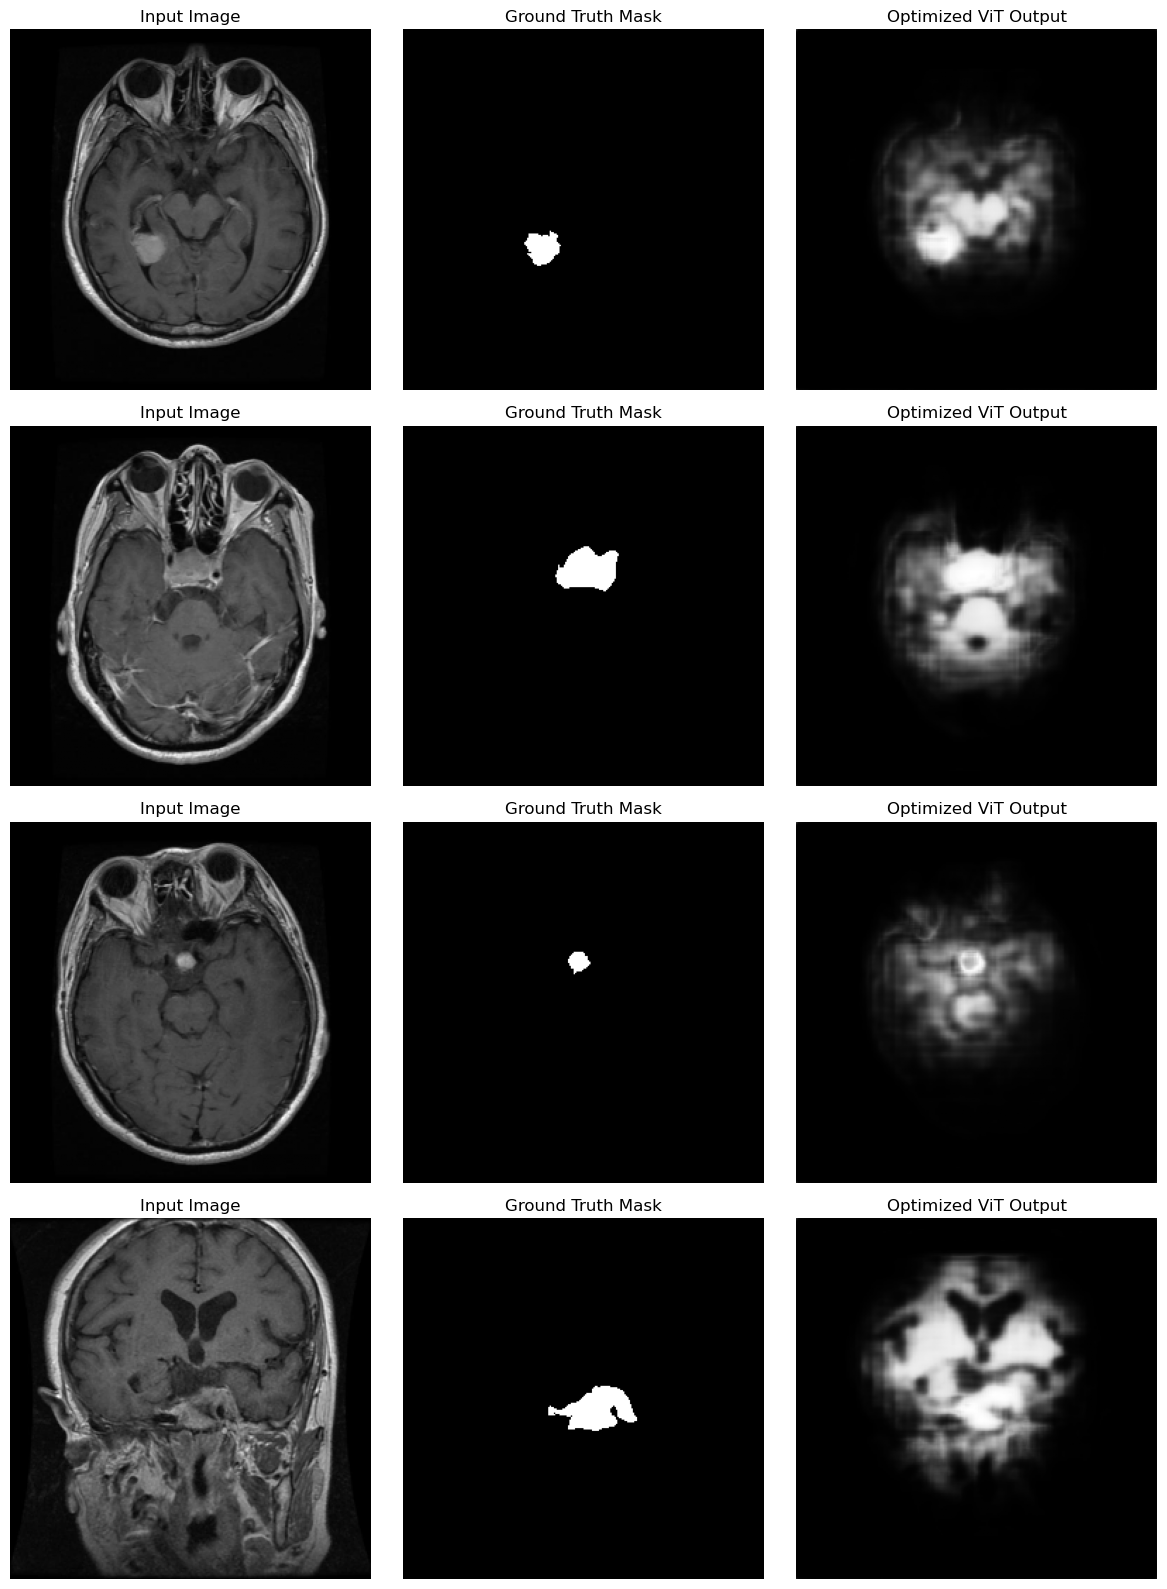

In [36]:
model.load_weights("best_optimized_model.keras")

inputs, true_masks = next(val_gen)
pred_masks = model.predict(inputs)

num_samples = min(4, len(true_masks))

plt.figure(figsize=(12, 4 * num_samples))

for i in range(num_samples):
    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(inputs["image_input"][i, ..., 0], cmap="gray")
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(true_masks[i, ..., 0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(pred_masks[i, ..., 0], cmap="gray")
    plt.title("Optimized ViT Output")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
val_loss, val_dice, val_iou = model.evaluate(
    val_gen,
    steps=validation_steps
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Dice: {val_dice:.4f}")
print(f"Validation IoU: {val_iou:.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - dice_coef: 0.2099 - iou_metric: 0.1193 - loss: 0.1088
Validation Loss: 0.1088
Validation Dice: 0.2099
Validation IoU: 0.1193


In [38]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

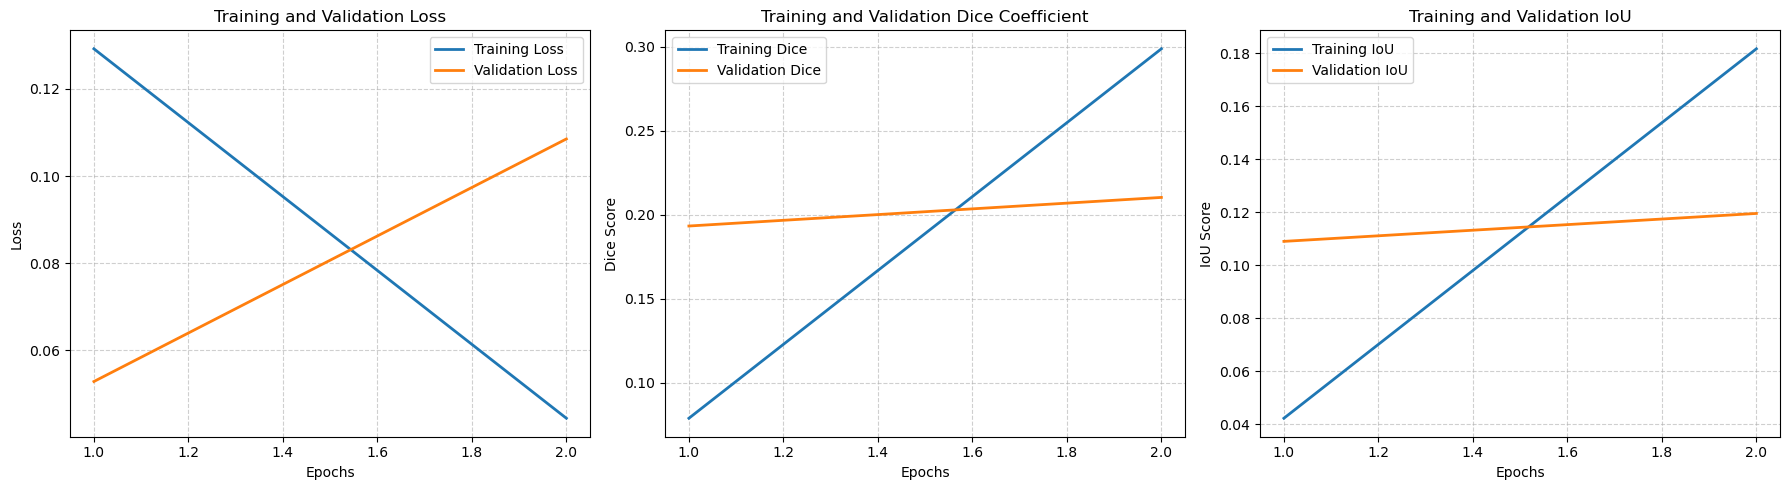

In [39]:
epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(18, 5))

# Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history.history["loss"], label="Training Loss", lw=2)
plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss", lw=2)
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Dice
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history.history["dice_coef"], label="Training Dice", lw=2)
plt.plot(epochs_range, history.history["val_dice_coef"], label="Validation Dice", lw=2)
plt.title("Training and Validation Dice Coefficient")
plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# IoU
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history.history["iou_metric"], label="Training IoU", lw=2)
plt.plot(epochs_range, history.history["val_iou_metric"], label="Validation IoU", lw=2)
plt.title("Training and Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [40]:
print("Gathering validation samples for pixel-level evaluation...")

all_true_pixels = []
all_pred_pixels = []

for step in range(validation_steps):
    inputs, true_masks = next(val_gen)

    preds = model.predict(inputs, verbose=0)

    binarized_preds = (preds > 0.5).astype(np.uint8)
    binarized_trues = (true_masks > 0.5).astype(np.uint8)

    all_true_pixels.append(binarized_trues.flatten())
    all_pred_pixels.append(binarized_preds.flatten())

y_true_pixels = np.concatenate(all_true_pixels)
y_pred_pixels = np.concatenate(all_pred_pixels)

Gathering validation samples for pixel-level evaluation...


In [41]:
cm = confusion_matrix(y_true_pixels, y_pred_pixels)

print("\n=== Pixel-Level Confusion Matrix ===")
print(cm)


=== Pixel-Level Confusion Matrix ===
[[48183417  2275587]
 [  323946   531738]]


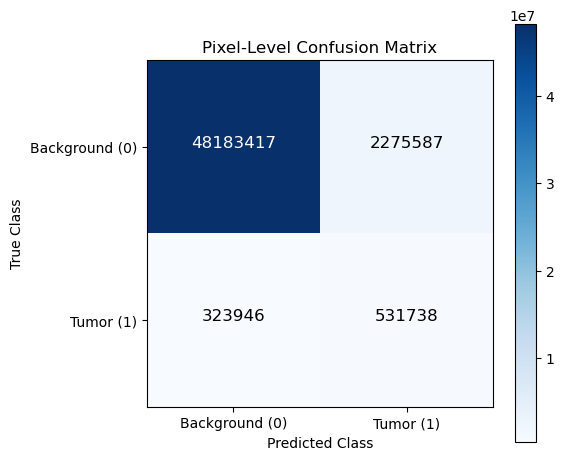

In [42]:
plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Pixel-Level Confusion Matrix")
plt.colorbar()

classes = ["Background (0)", "Tumor (1)"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0

for i, j in np.ndindex(cm.shape):
    plt.text(
        j,
        i,
        format(cm[i, j], "d"),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
        fontsize=12
    )

plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

In [43]:
print("\n=== Pixel-Level Classification Report ===")

print(
    classification_report(
        y_true_pixels,
        y_pred_pixels,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)


=== Pixel-Level Classification Report ===
                precision    recall  f1-score   support

Background (0)     0.9933    0.9549    0.9737  50459004
     Tumor (1)     0.1894    0.6214    0.2903    855684

      accuracy                         0.9493  51314688
     macro avg     0.5914    0.7882    0.6320  51314688
  weighted avg     0.9799    0.9493    0.9623  51314688



__End of the analysis__